In [1]:
"""
Created on: 18-08-2026

@author B.A. Sturre

PyTorch tutorial 
https://www.youtube.com/watch?v=c36lUUr864M 

the data can be downloaded from https://www.kaggle.com/datasets/thedatasith/hymenoptera?resource=download 
"""

import copy 
import matplotlib.pyplot as plt 
import numpy as np 
import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F 
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms

## Transfer learning

We will be using resnet18 CNN, trained on more than 1 million images, 18 layers deep. We only want to detect bees and ants. 

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

mean = np.array([0.5, 0.5, 0.5])
std = np.array([0.25, 0.25, 0.25])

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
}

data_dir = 'data/hymenoptera'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=0)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(class_names)

['ants', 'bees']


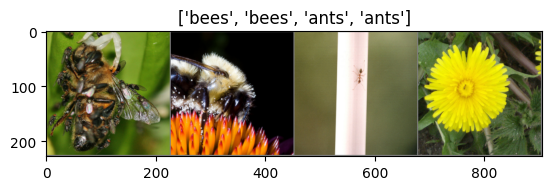

In [3]:
def imshow(inp, title):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    plt.title(title)
    plt.show()


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [4]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch + 1, num_epochs))

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

In [5]:
# importing the pretrained model 
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# number of input features for the last layer 
num_ftrs = model.fc.in_features  # fc: fully connected

# new layer assigned to last layer
model.fc = nn.Linear(num_ftrs, 2)  # 2 classes: bee and ant
model = model.to(device)

# loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)  # observe that all parameters are being optimized

# scheduler: decays the learning rate of each parameter group by gamma (by multiplication) every step_size epochs
# should be applied after optimizer's update by using scheduler.step()
step_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

model = train_model(model, criterion, optimizer, step_lr_scheduler, num_epochs=25)

Epoch 1/25
train Loss: 0.6640 Acc: 0.5656
val Loss: 0.5242 Acc: 0.7582

Epoch 2/25
train Loss: 0.5708 Acc: 0.7459
val Loss: 0.3698 Acc: 0.8824

Epoch 3/25
train Loss: 0.4514 Acc: 0.8074
val Loss: 0.3005 Acc: 0.9085

Epoch 4/25
train Loss: 0.4291 Acc: 0.8320
val Loss: 0.2588 Acc: 0.9085

Epoch 5/25
train Loss: 0.3891 Acc: 0.8238
val Loss: 0.2379 Acc: 0.9085

Epoch 6/25
train Loss: 0.3703 Acc: 0.8648
val Loss: 0.2243 Acc: 0.9150

Epoch 7/25
train Loss: 0.3874 Acc: 0.8197
val Loss: 0.2291 Acc: 0.9216

Epoch 8/25
train Loss: 0.4018 Acc: 0.8074
val Loss: 0.2197 Acc: 0.9281

Epoch 9/25
train Loss: 0.3235 Acc: 0.8689
val Loss: 0.2288 Acc: 0.9216

Epoch 10/25
train Loss: 0.3278 Acc: 0.8566
val Loss: 0.2484 Acc: 0.9281

Epoch 11/25
train Loss: 0.3778 Acc: 0.8074
val Loss: 0.2343 Acc: 0.9216

Epoch 12/25
train Loss: 0.3434 Acc: 0.8402
val Loss: 0.2275 Acc: 0.9281

Epoch 13/25
train Loss: 0.3069 Acc: 0.8689
val Loss: 0.2435 Acc: 0.9150

Epoch 14/25
train Loss: 0.3286 Acc: 0.8484
val Loss: 0.2221 

Other option: freeze all the layers in the beginning and only train the very last layer

In [6]:
# importing the pretrained model 
model_conv = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model_conv.parameters():
    param.requires_grad = False 

num_ftrs = model_conv.fc.in_features 
model_conv.fc = nn.Linear(num_ftrs, 2)  # 2 classes: bee and ant
model_conv = model_conv.to(device)

# loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer_conv = optim.SGD(model_conv.parameters(), lr=0.001, momentum=0.9)  # observe that only parameters of last layer are being optimized

# scheduler
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

model_conv = train_model(model_conv, criterion, optimizer_conv, exp_lr_scheduler, num_epochs=25)

Epoch 1/25
train Loss: 0.6216 Acc: 0.6434
val Loss: 0.3086 Acc: 0.8889

Epoch 2/25
train Loss: 0.4168 Acc: 0.8197
val Loss: 0.1983 Acc: 0.9346

Epoch 3/25
train Loss: 0.5186 Acc: 0.7459
val Loss: 0.2189 Acc: 0.9412

Epoch 4/25
train Loss: 0.4096 Acc: 0.8525
val Loss: 0.3094 Acc: 0.8889

Epoch 5/25
train Loss: 0.3561 Acc: 0.8484
val Loss: 0.2121 Acc: 0.9412

Epoch 6/25
train Loss: 0.5186 Acc: 0.7992
val Loss: 0.2035 Acc: 0.9346

Epoch 7/25
train Loss: 0.3214 Acc: 0.8689
val Loss: 0.2104 Acc: 0.9412

Epoch 8/25
train Loss: 0.4644 Acc: 0.8033
val Loss: 0.2186 Acc: 0.9281

Epoch 9/25
train Loss: 0.4455 Acc: 0.8197
val Loss: 0.2472 Acc: 0.9346

Epoch 10/25
train Loss: 0.3957 Acc: 0.8484
val Loss: 0.2675 Acc: 0.9085

Epoch 11/25
train Loss: 0.3940 Acc: 0.8033
val Loss: 0.1879 Acc: 0.9477

Epoch 12/25
train Loss: 0.4936 Acc: 0.7992
val Loss: 0.3341 Acc: 0.8954

Epoch 13/25
train Loss: 0.5806 Acc: 0.7787
val Loss: 0.3406 Acc: 0.8954

Epoch 14/25
train Loss: 0.4222 Acc: 0.8238
val Loss: 0.2252 